<a href="https://colab.research.google.com/github/maybraniswe/Retail-Store-Sales-Analysis-and-Prediction/blob/main/PDSE%20Project_Retail%20Store%20Sales%20Analysis%20and%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Retail Store Sales Analysis and Prediction**

##**Introduction**
In the modern retail environment, businesses rely on data to understand customer behavior and improve sales performance. Retail transaction data contains valuable information such as product categories, pricing, quantity purchased, and customer purchasing patterns. Analyzing this data helps identify trends, improve decision-making, and support business growth.
This project focuses on a Retail Store Sales dataset, which includes transaction details such as customer ID, product category, item purchased, price per unit, quantity, total spending, payment method, and transaction date.
The project follows a complete data science workflow, including data cleaning, exploratory data analysis (EDA), predictive modeling, and visualization, to generate meaningful insights and support data-driven decisions.

##**Objective**

**Problem Statement**
* To analyze retail sales data and understand factors that influence customer spending and sales performance.

**Data Description**
* To explore and understand the structure of the dataset, including features such as category, item, price, quantity, total spent, and transaction details.

**Data Cleaning & Preprocessing**
* To handle missing values, incorrect data types, and inconsistencies in the dataset to ensure data quality.

**Exploratory Data Analysis (EDA)**
* To analyze patterns and relationships using:
   * Univariate analysis (distribution of variables)
   * Bivariate analysis (relationships between variables)
   * Multivariate analysis (correlation and combined effects)

**Model Development & Tuning**
* To apply at least two machine learning models to predict outcomes such as total spending or customer behavior.
* To improve model performance through parameter tuning.

**Results & Insights**
* To interpret model results and extract meaningful insights from the analysis.

**Visualization & Communication**
* To present findings clearly using charts, graphs, and visualizations.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler

##Data Loading

In [2]:
# read the data from csv file
df = pd.read_csv('https://raw.githubusercontent.com/maybraniswe/Retail-Store-Sales-Analysis-and-Prediction/refs/heads/main/retail_store_sales.csv')
# Dataset size check (rows, columns)
print (df.shape)

(12575, 11)


In [3]:
# View data the first 5 rows
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [4]:
# View data the first 5 rows
df.tail()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True
12574,TXN_2407494,CUST_23,Food,Item_9_FOOD,17.0,3.0,51.0,Cash,Online,2022-08-06,NaN


##Handling Duplicates

In [5]:
# Remove duplicate rows
print("Duplicate rows before:", df.duplicated().sum())

Duplicate rows before: 0


##Converting Data Types

In [6]:
# Convert numeric columns
num_cols = ['Price Per Unit', 'Quantity', 'Total Spent', 'Discount Applied']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert date column
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

# Convert categorical columns
cat_cols = ['Transaction ID', 'Customer ID', 'Category', 'Item', 'Payment Method', 'Location']
for col in cat_cols:
    df[col] = df[col].astype('category')

print(df.dtypes)

Transaction ID            category
Customer ID               category
Category                  category
Item                      category
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method            category
Location                  category
Transaction Date    datetime64[ns]
Discount Applied           float64
dtype: object


In [7]:
# Check summary statistics
df.describe().round(2)

,Price Per Unit,Quantity,Total Spent,Transaction Date,Discount Applied
count,11966.00,11971.00,11971.00,12575,8376.0
mean,23.37,5.54,129.65,2023-07-12 20:23:41.105368064,0.5
min,5.00,1.00,5.00,2022-01-01 00:00:00,0.0
25%,14.00,3.00,51.00,2022-09-30 00:00:00,0.0
50%,23.00,6.00,108.50,2023-07-13 00:00:00,1.0
75%,33.50,8.00,192.00,2024-04-24 00:00:00,1.0
max,41.00,10.00,410.00,2025-01-18 00:00:00,1.0
std,10.74,2.86,94.75,NaN,0.5


In [8]:
# Check structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  category      
 1   Customer ID       12575 non-null  category      
 2   Category          12575 non-null  category      
 3   Item              11362 non-null  category      
 4   Price Per Unit    11966 non-null  float64       
 5   Quantity          11971 non-null  float64       
 6   Total Spent       11971 non-null  float64       
 7   Payment Method    12575 non-null  category      
 8   Location          12575 non-null  category      
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  8376 non-null   float64       
dtypes: category(6), datetime64[ns](1), float64(4)
memory usage: 956.9 KB


In [9]:
# Checking for missing values
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


In [10]:
df.nunique()

,0
Transaction ID,12575
Customer ID,25
Category,8
Item,200
Price Per Unit,25
Quantity,10
Total Spent,227
Payment Method,3
Location,2
Transaction Date,1114


In [11]:
df['Item'].nunique()

200

In [12]:
# Best selling Item analysis
df['Item'].value_counts()

,count
Item,
Item_2_BEV,126
Item_25_FUR,113
Item_11_FUR,110
Item_16_MILK,109
Item_1_MILK,109
...,...
Item_13_BEV,7
Item_5_BEV,7
Item_24_CEA,7


In [13]:
df.groupby('Item')['Price Per Unit'].describe()

/tmp/ipykernel_8102/98603682.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Item')['Price Per Unit'].describe()


,count,mean,std,min,25%,50%,75%,max
Item,,,,,,,,
Item_10_BEV,23.0,18.5,0.0,18.5,18.5,18.5,18.5,18.5
Item_10_BUT,16.0,18.5,0.0,18.5,18.5,18.5,18.5,18.5
Item_10_CEA,73.0,18.5,0.0,18.5,18.5,18.5,18.5,18.5
Item_10_EHE,41.0,18.5,0.0,18.5,18.5,18.5,18.5,18.5
Item_10_FOOD,56.0,18.5,0.0,18.5,18.5,18.5,18.5,18.5
...,...,...,...,...,...,...,...,...
Item_9_EHE,59.0,17.0,0.0,17.0,17.0,17.0,17.0,17.0
Item_9_FOOD,71.0,17.0,0.0,17.0,17.0,17.0,17.0,17.0
Item_9_FUR,14.0,17.0,0.0,17.0,17.0,17.0,17.0,17.0


## Missing Values

In [14]:
# Fill missing numeric values using median (for outliers)
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].median())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

# Recalculate Total Spent
df['Total Spent'] = df['Price Per Unit'] * df['Quantity']

# Fill Discount Applied with 0 (assume no discount)
df['Discount Applied'] = df['Discount Applied'].fillna(0)

# Fill Item using group based method
df['Item'] = df.groupby('Price Per Unit')['Item'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'unknown')
)
print (df.isnull().sum())


Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64


##Standardizing Inconsistent Data

In [15]:
# Clean text data (remove spaces, lowercase)
df['Item'] = df['Item'].str.strip().str.lower()
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,item_10_pat,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,1.0
1,TXN_3731986,CUST_22,Milk Products,item_17_milk,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,1.0
2,TXN_9303719,CUST_02,Butchers,item_12_but,21.5,2.0,43.0,Credit Card,Online,2022-10-05,0.0
3,TXN_9458126,CUST_06,Beverages,item_16_bev,27.5,9.0,247.5,Credit Card,Online,2022-05-07,0.0
4,TXN_4575373,CUST_05,Food,item_6_food,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,0.0


##Handling Duplicates

In [16]:
# Remove duplicate rows
print("Duplicate rows after:", df.duplicated().sum())

Duplicate rows after: 0


##Univariate Analysis

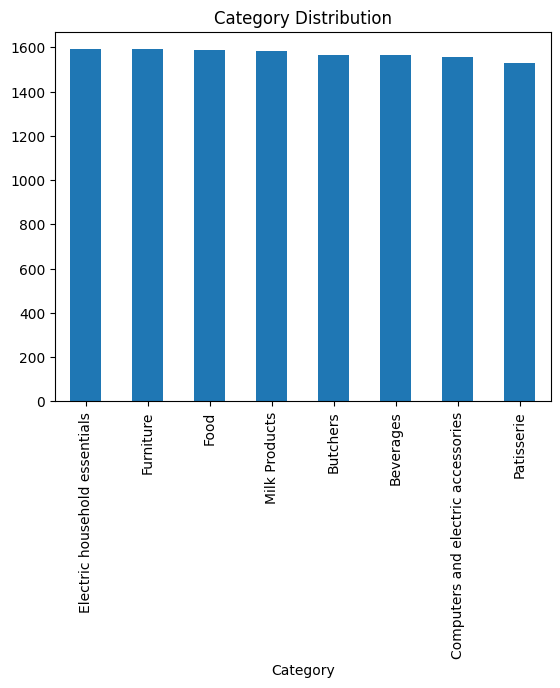

In [17]:
# Category (Bar chart)
df['Category'].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.show()

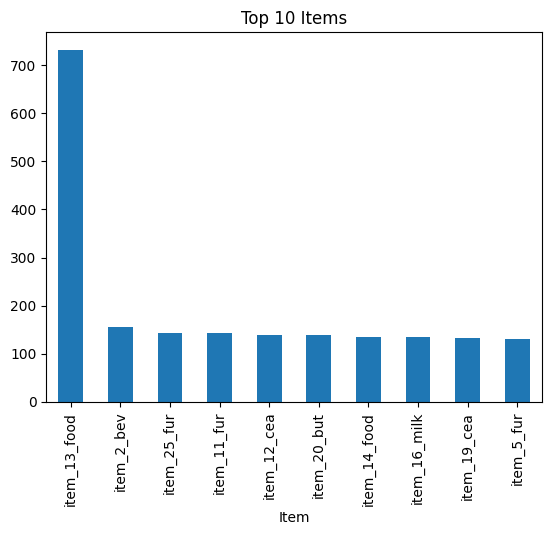

In [18]:
# Item (Top 10 items)
df['Item'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Items")
plt.show()

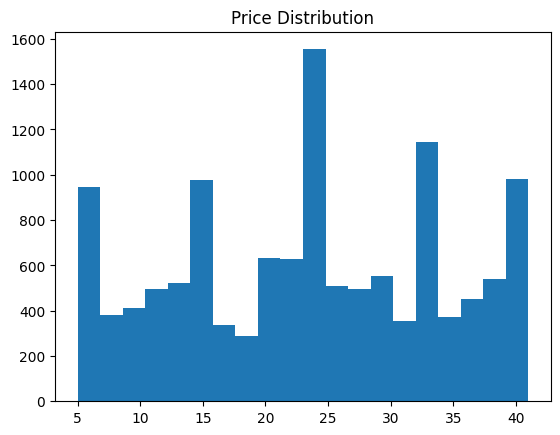

In [19]:
# Price Per Unit (Histogram)
plt.hist(df['Price Per Unit'], bins=20)
plt.title("Price Distribution")
plt.show()

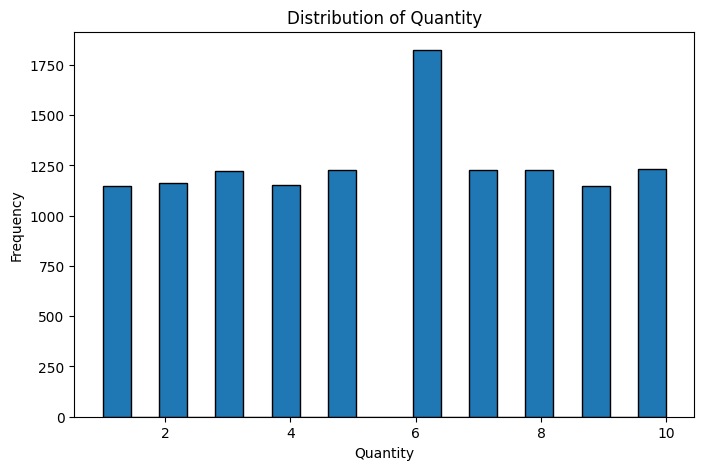

In [20]:
plt.figure(figsize=(8,5))
plt.hist(df['Quantity'], bins=20, edgecolor='black')
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

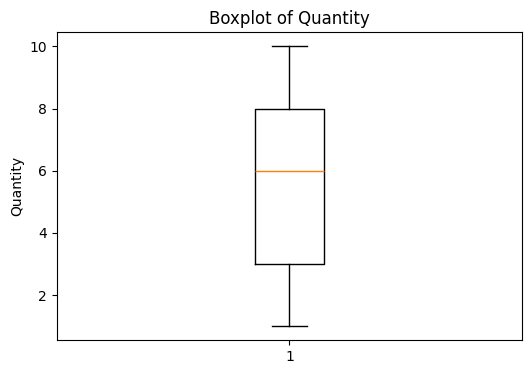

In [21]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Quantity'])
plt.title('Boxplot of Quantity')
plt.ylabel('Quantity')
plt.show()

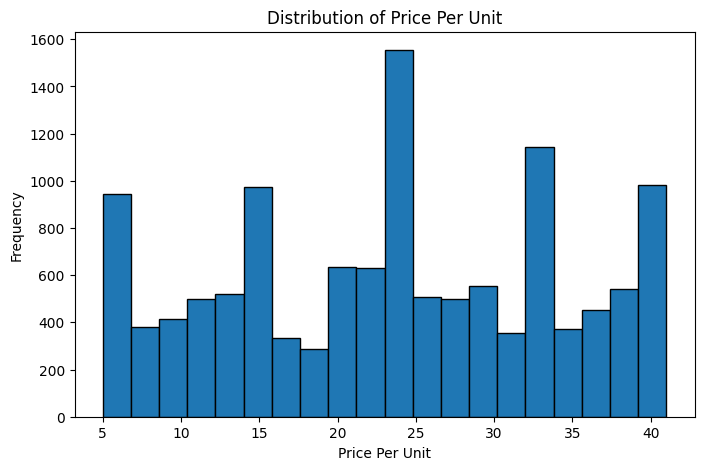

In [22]:
plt.figure(figsize=(8,5))
plt.hist(df['Price Per Unit'], bins=20, edgecolor='black')
plt.title('Distribution of Price Per Unit')
plt.xlabel('Price Per Unit')
plt.ylabel('Frequency')
plt.show()

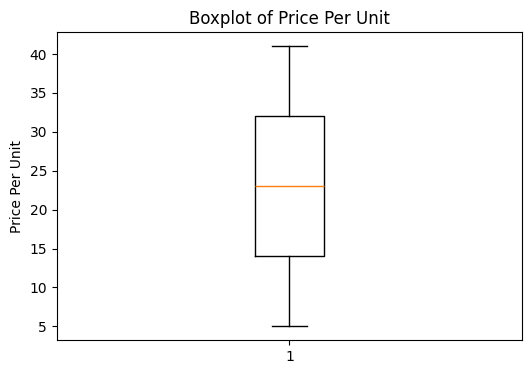

In [23]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Price Per Unit'])
plt.title('Boxplot of Price Per Unit')
plt.ylabel('Price Per Unit')
plt.show()

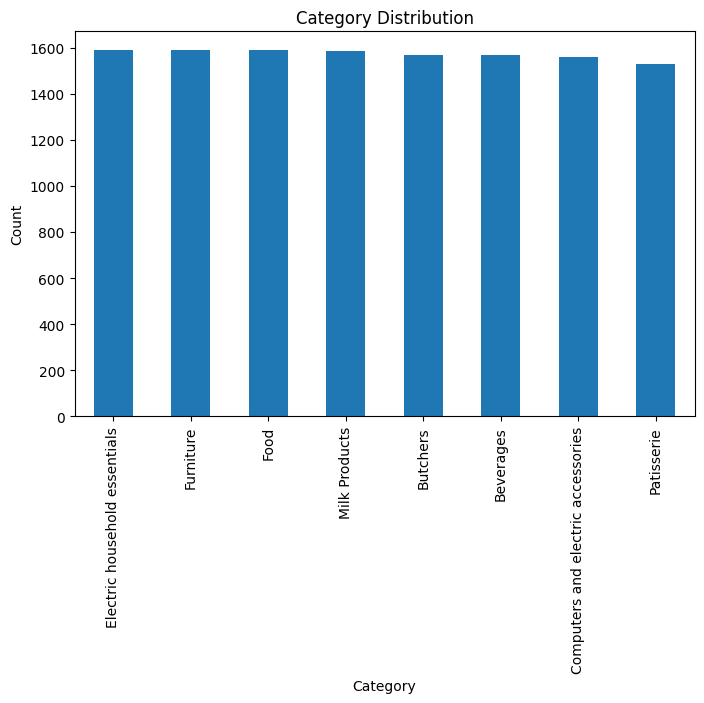

In [24]:
plt.figure(figsize=(8,5))
df['Category'].value_counts().plot(kind='bar')
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

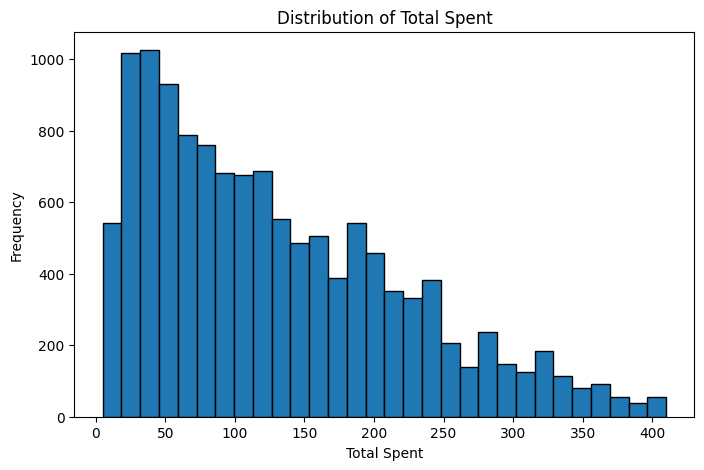

In [25]:
plt.figure(figsize=(8,5))
plt.hist(df['Total Spent'], bins=30, edgecolor='black')
plt.title('Distribution of Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.show()

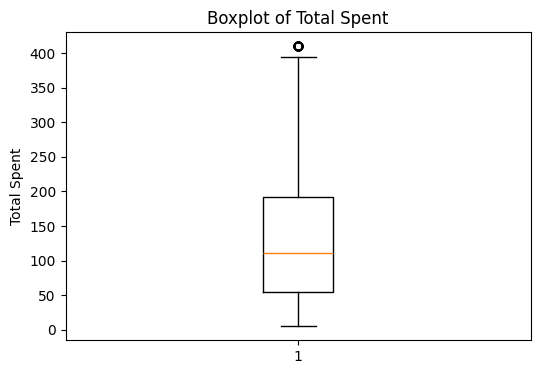

In [26]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Total Spent'])
plt.title('Boxplot of Total Spent')
plt.ylabel('Total Spent')
plt.show()

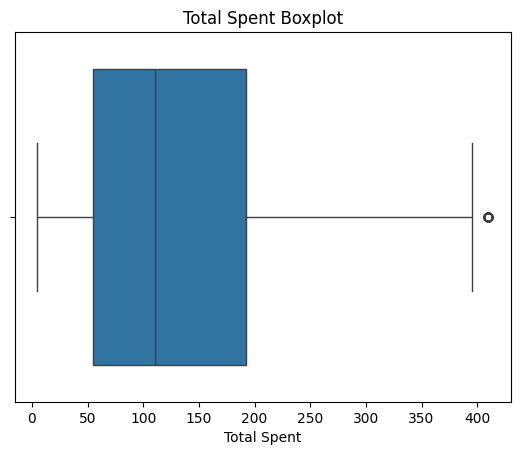

In [27]:
# Total Spent (Boxplot)
sns.boxplot(x=df['Total Spent'])
plt.title("Total Spent Boxplot")
plt.show()

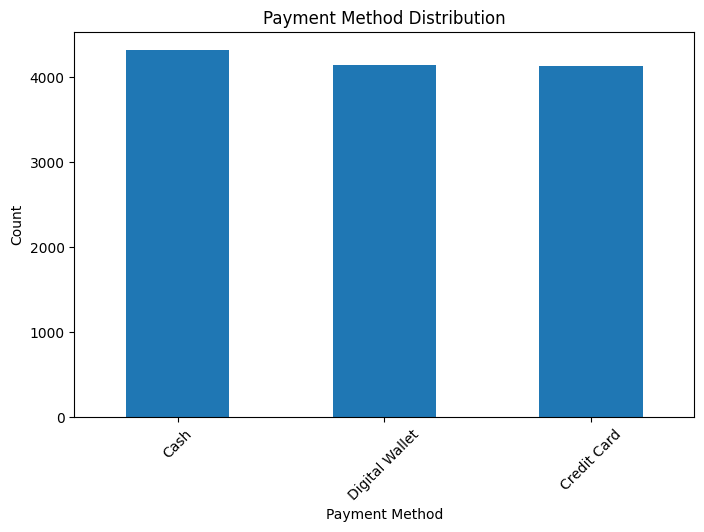

In [28]:
plt.figure(figsize=(8,5))
df['Payment Method'].value_counts().plot(kind='bar')
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

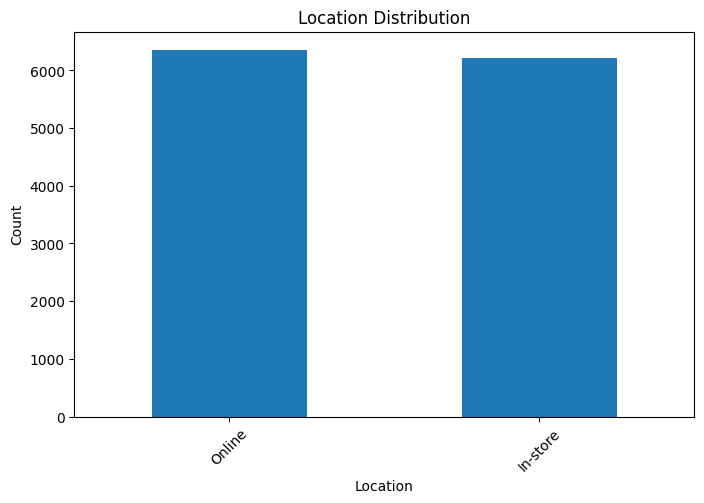

In [29]:
plt.figure(figsize=(8,5))
df['Location'].value_counts().plot(kind='bar')
plt.title('Location Distribution')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

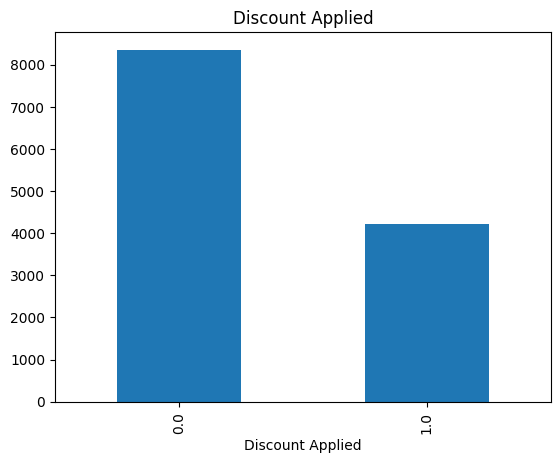

In [30]:
# Discount Applied (Bar chart)
df['Discount Applied'].value_counts().plot(kind='bar')
plt.title("Discount Applied")
plt.show()

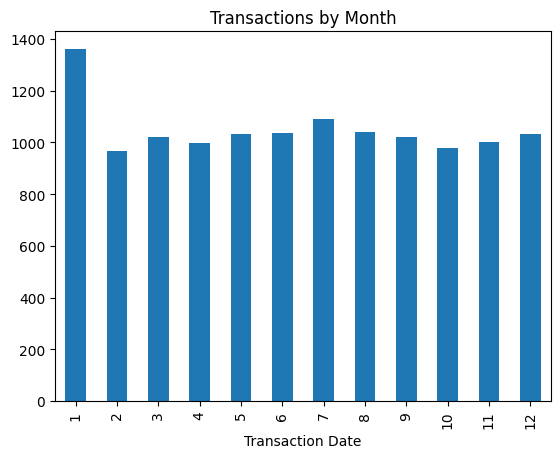

In [31]:
# Transaction Date (by month)

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

df['Transaction Date'].dt.month.value_counts().sort_index().plot(kind='bar')
plt.title("Transactions by Month")
plt.show()

##Multivariate Analysis

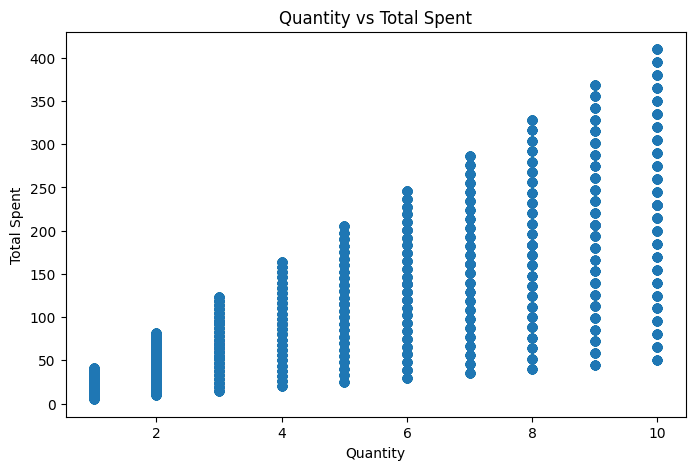

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(df['Quantity'], df['Total Spent'], alpha=0.5)
plt.title('Quantity vs Total Spent')
plt.xlabel('Quantity')
plt.ylabel('Total Spent')
plt.show()

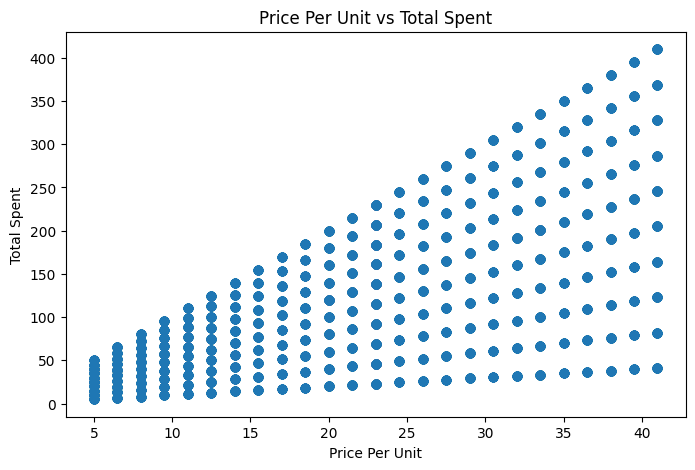

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(df['Price Per Unit'], df['Total Spent'], alpha=0.5)
plt.title('Price Per Unit vs Total Spent')
plt.xlabel('Price Per Unit')
plt.ylabel('Total Spent')
plt.show()

/tmp/ipykernel_8102/2772231249.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=categories)


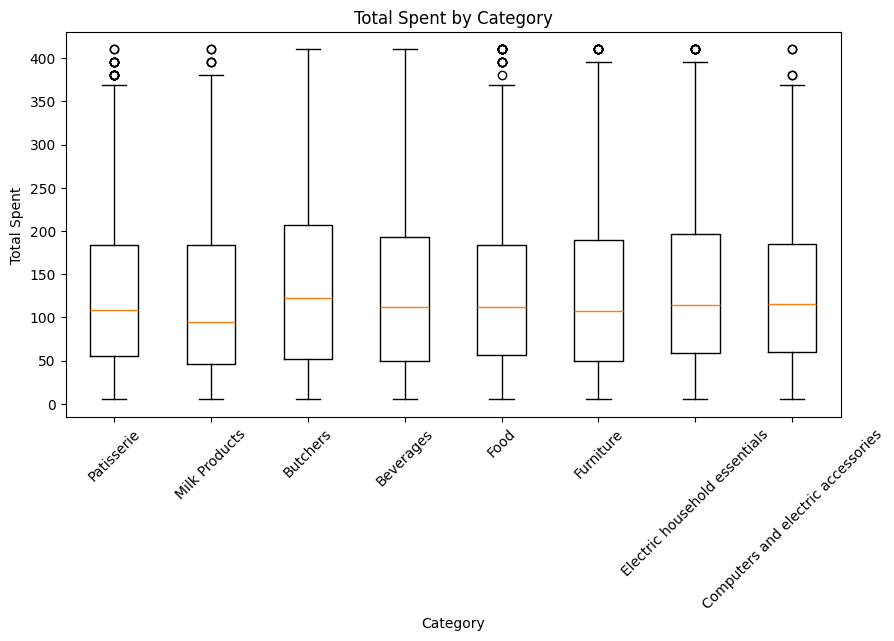

In [34]:
plt.figure(figsize=(10,5))
categories = df['Category'].dropna().unique()
data = [df[df['Category'] == cat]['Total Spent'] for cat in categories]

plt.boxplot(data, labels=categories)
plt.title('Total Spent by Category')
plt.xlabel('Category')
plt.ylabel('Total Spent')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_8102/1938050099.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=methods)


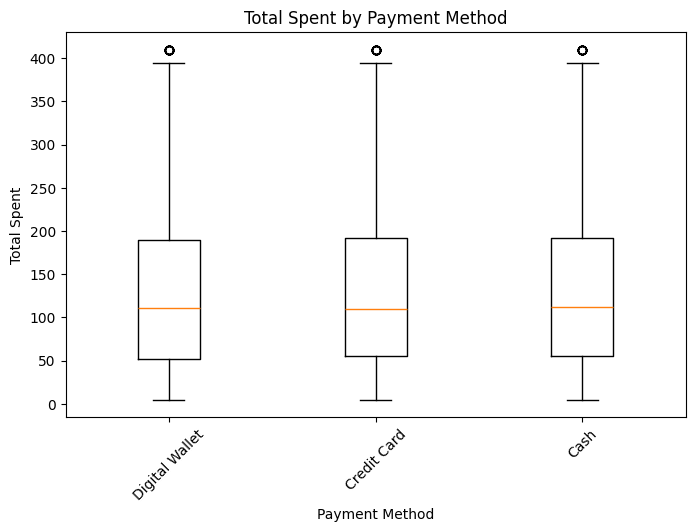

In [35]:
plt.figure(figsize=(8,5))
methods = df['Payment Method'].dropna().unique()
data = [df[df['Payment Method'] == method]['Total Spent'] for method in methods]

plt.boxplot(data, labels=methods)
plt.title('Total Spent by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Spent')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_8102/1972529065.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=locations)


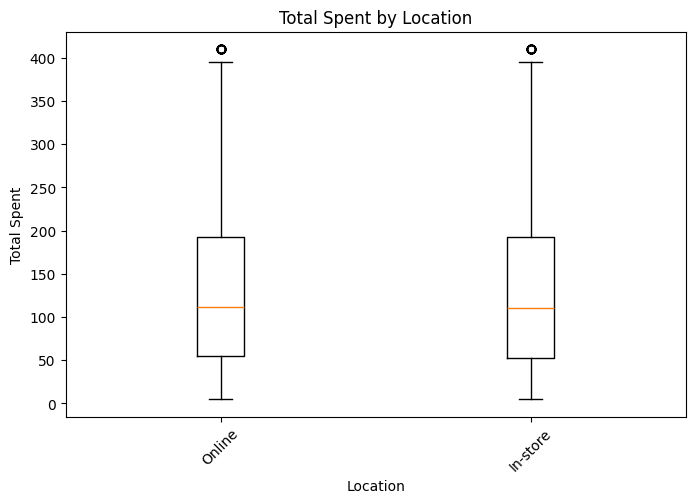

In [36]:
plt.figure(figsize=(8,5))
locations = df['Location'].dropna().unique()
data = [df[df['Location'] == loc]['Total Spent'] for loc in locations]

plt.boxplot(data, labels=locations)
plt.title('Total Spent by Location')
plt.xlabel('Location')
plt.ylabel('Total Spent')
plt.xticks(rotation=45)
plt.show()

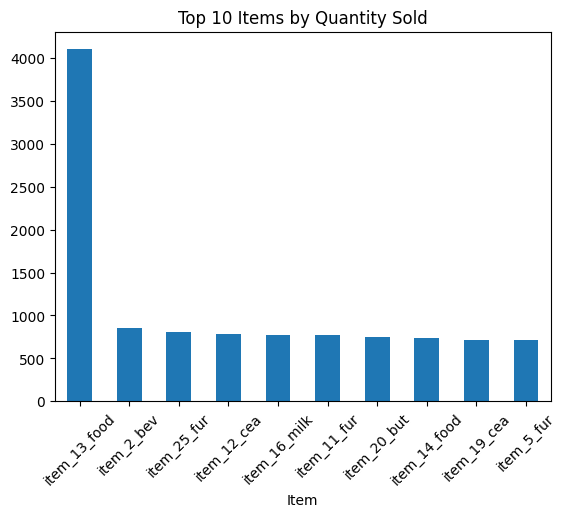

In [37]:
top_qty = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(10)

top_qty.plot(kind='bar')
plt.title("Top 10 Items by Quantity Sold")
plt.xticks(rotation=45)
plt.show()

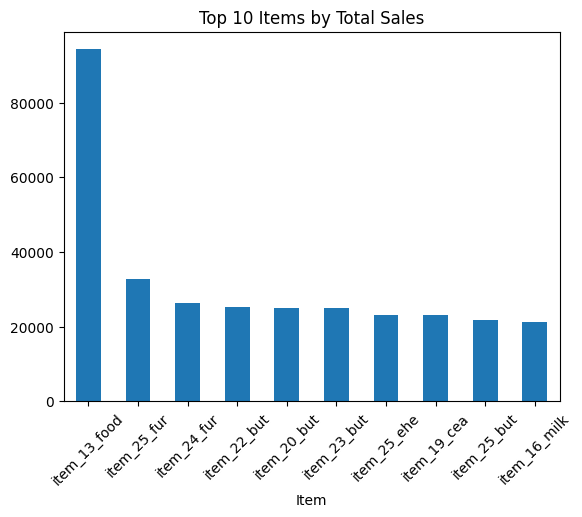

In [38]:
top_items = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False).head(10)

top_items.plot(kind='bar')
plt.title("Top 10 Items by Total Sales")
plt.xticks(rotation=45)
plt.show()

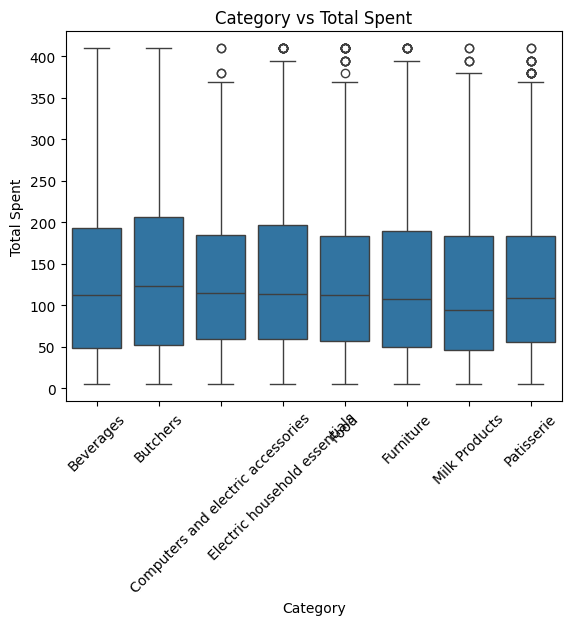

In [39]:
sns.boxplot(x='Category', y='Total Spent', data=df)
plt.xticks(rotation=45)
plt.title("Category vs Total Spent")
plt.show()

##Heatmap

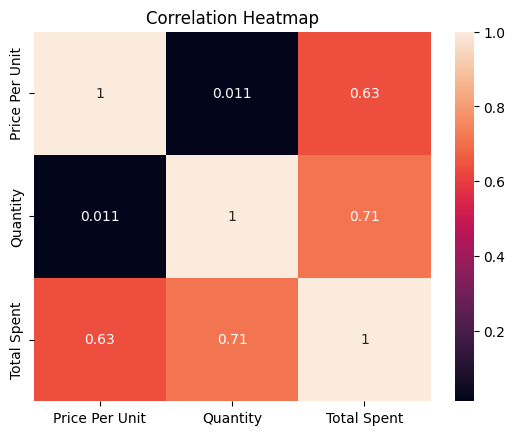

In [40]:
corr = df[['Price Per Unit', 'Quantity', 'Total Spent']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

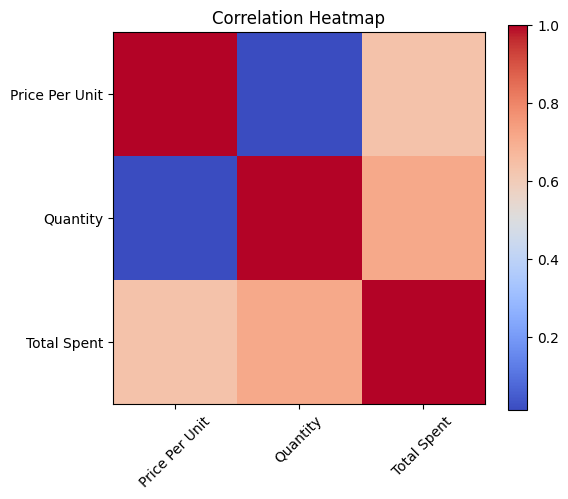

In [41]:
corr = df[['Price Per Unit', 'Quantity', 'Total Spent']].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.show()

In [42]:
pivot_table = df.pivot_table(
    values='Total Spent',
    index='Category',
    columns='Payment Method',
    aggfunc='mean'
)

print(pivot_table)

Payment Method                            Cash  Credit Card  Digital Wallet
Category                                                                   
Beverages                           127.220690   133.862213      135.254921
Butchers                            144.061538   138.585895      133.024242
Computers and electric accessories  132.617916   129.002890      127.762195
Electric household essentials       131.186456   129.861396      140.618584
Food                                132.108036   131.253953      125.074713
Furniture                           133.196395   129.000000      125.017790
Milk Products                       121.597723   118.200555      121.800388
Patisserie                          130.602941   125.857708      125.486328


/tmp/ipykernel_8102/3075368852.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(
